In [1]:
import pandas as pd
import networkx as nx
import json
from collections import defaultdict
import community.community_louvain as community_louvain
from matplotlib import pyplot as plt
import numpy as np
import random
import itertools

In [2]:
def represent_degree_distribution(G,node_list,scale='linear',rep='bars', title=''):
    degree_sequence=[G.degree(node) for node in node_list]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees=list(degree_counts.keys())
    degree_count=list(degree_counts.values())

    fig,ax=plt.subplots(1,1,figsize=(5,5))
    if rep=='bars':
        ax.bar(degrees,degree_count)
    if rep=='scatter':
        ax.scatter(degrees,degree_count)
    
    if scale=='log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.set_xlabel('Degree',fontsize=15)
    ax.set_ylabel('#nodes',fontsize=15)
    ax.tick_params(which='major',axis='both',labelsize=15) 
    ax.set_title(title)

In [3]:
def fit_CCDF(G,node_list, title=''):
    degree_sequence=[G.degree(node) for node in node_list]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_count = [degree_counts.get(k, 0) for k in degrees]

    degrees=[degrees[i] for i in range(len(degrees)) if degree_count[i]!=0]
    degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

    
    cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
    ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

    log_degree_fit=[np.log(degrees[i]) for i in range(len(degrees))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
    log_ccdf_fit=np.log(ccdf)[:-1]

    m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

    theoretical=[np.exp(b)*k**m for k in degrees]

    fig,ax=plt.subplots(1,1,figsize=(5,5))

    ax.plot(degrees, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
    ax.scatter(degrees, ccdf,label='data')


    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel('$k$',fontsize=15)
    ax.set_ylabel('$CCDF(k)$',fontsize=15)

    ax.tick_params(which='major',axis='both',labelsize=15)

    ax.legend()
    ax.set_title(title)

In [4]:
# =========================================================
# LOAD JSON
# =========================================================

with open(
    "./doi_10_5061_dryad_dr7sqv9v8__v20200626/"
    "NJC19_network_data_and_code/"
    "NJC19_network.json"
) as f:

    data = json.load(f)

# =========================================================
# CREATE DIRECTED BIPARTITE MULTIGRAPH
# =========================================================
#
# WHY MultiDiGraph?
#
# - Multi:
#   same species/metabolite pair can have
#   multiple interaction types
#
# - Di:
#   direction represents metabolic flow
#
# - Bipartite:
#   species and metabolites are separate node sets
#
# =========================================================

B = nx.MultiDiGraph()

# =========================================================
# ACTIVITY CLASSIFICATION
# =========================================================

activity_map = {

    "Consumption (import)": {
        "category": "import",
        "sign": 1
    },

    "Production (export)": {
        "category": "export",
        "sign": 1
    },

    "Consumption (import), Production (export)": {
        "category": "exchange",
        "sign": 1
    },

    "Macromolecule degradation": {
        "category": "degradation",
        "sign": 1
    },

    "Consumption (import) (-)": {
        "category": "import",
        "sign": -1
    },

    "Production (export) (-)": {
        "category": "export",
        "sign": -1
    },

    "Macromolecule degradation (-)": {
        "category": "degradation",
        "sign": -1
    }
}

# =========================================================
# BUILD NETWORK
# =========================================================

for interaction_id, interaction in data.items():

    # -----------------------------------------------------
    # Extract fields
    # -----------------------------------------------------

    species = interaction["Species"].strip().lower()

    metabolite = interaction[
        "Small-molecule metabolite or macromolecule"
    ].strip().lower()

    activity = interaction["Metabolic activity"]

    refs = interaction["Ref. #"]

    # -----------------------------------------------------
    # Parse activity metadata
    # -----------------------------------------------------

    parsed = activity_map[activity]

    category = parsed["category"]
    sign = parsed["sign"]

    # -----------------------------------------------------
    # Add species node
    # -----------------------------------------------------

    B.add_node(
        species,

        bipartite=0,
        node_type="species",

        label=species
    )

    # -----------------------------------------------------
    # Add metabolite node
    # -----------------------------------------------------

    B.add_node(
        metabolite,

        bipartite=1,
        node_type="metabolite",

        label=metabolite
    )

    # =====================================================
    # DEFINE EDGE DIRECTION
    # =====================================================
    #
    # IMPORT:
    # metabolite -> species
    #
    # EXPORT:
    # species -> metabolite
    #
    # EXCHANGE:
    # both directions
    #
    # DEGRADATION:
    # metabolite -> species
    #
    # =====================================================

    # -----------------------------------------------------
    # IMPORT
    # -----------------------------------------------------

    if category == "import":

        B.add_edge(
            metabolite,
            species,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # EXPORT
    # -----------------------------------------------------

    elif category == "export":

        B.add_edge(
            species,
            metabolite,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # EXCHANGE
    # -----------------------------------------------------

    elif category == "exchange":

        # species exports metabolite
        B.add_edge(
            species,
            metabolite,

            interaction_id=f"{interaction_id}_export",

            activity=activity,
            category="export",

            sign=sign,

            refs=refs
        )

        # species imports metabolite
        B.add_edge(
            metabolite,
            species,

            interaction_id=f"{interaction_id}_import",

            activity=activity,
            category="import",

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # DEGRADATION
    # -----------------------------------------------------

    elif category == "degradation":

        B.add_edge(
            metabolite,
            species,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

# =========================================================
# BASIC SUMMARY
# =========================================================

species_nodes = [
    n for n, d in B.nodes(data=True)
    if d["bipartite"] == 0
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d["bipartite"] == 1
]

print("=" * 60)
print("DIRECTED BIPARTITE METABOLIC NETWORK")
print("=" * 60)

print(f"Total nodes: {B.number_of_nodes()}")
print(f"Total edges: {B.number_of_edges()}")

print()

print(f"Species nodes: {len(species_nodes)}")
print(f"Metabolite nodes: {len(metabolite_nodes)}")

# =========================================================
# CHECK BIPARTITE STRUCTURE
# =========================================================

is_bipartite = nx.is_bipartite(B)

print()
print(f"Is bipartite: {is_bipartite}")


# =========================================================
# EDGE CATEGORY COUNTS
# =========================================================

from collections import Counter

edge_categories = Counter()

for _, _, data in B.edges(data=True):

    edge_categories[data["category"]] += 1

print()
print("Edge categories:")

for category, count in edge_categories.items():

    print(f"  {category}: {count}")

# =========================================================
# OPTIONAL:
# SHOW EXAMPLE EDGES
# =========================================================

print()
print("=" * 60)
print("EXAMPLE EDGES")
print("=" * 60)

for i, (u, v, d) in enumerate(B.edges(data=True)):

    print(
        f"{u} -> {v} | "
        f"{d['category']} | "
        f"sign={d['sign']}"
    )

    if i >= 9:
        break

DIRECTED BIPARTITE METABOLIC NETWORK
Total nodes: 1127
Total edges: 9316

Species nodes: 844
Metabolite nodes: 283

Is bipartite: True

Edge categories:
  export: 3041
  import: 5798
  degradation: 477

EXAMPLE EDGES
absiella dolichum -> acetate | export | sign=1
absiella dolichum -> butyrate | export | sign=1
absiella dolichum -> h2s (hs-) | export | sign=-1
absiella dolichum -> l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate) | export | sign=1
absiella dolichum -> nh3 (ammonia, nh4+, ammonium) | export | sign=1
absiella dolichum -> pyruvate | export | sign=1
absiella dolichum -> succinate | export | sign=1
acetate -> actinosynnema mirum | import | sign=-1
acetate -> alicycliphilus denitrificans | import | sign=1
acetate -> anaerobutyricum hallii | import | sign=1


## Analyzing the bipartite network

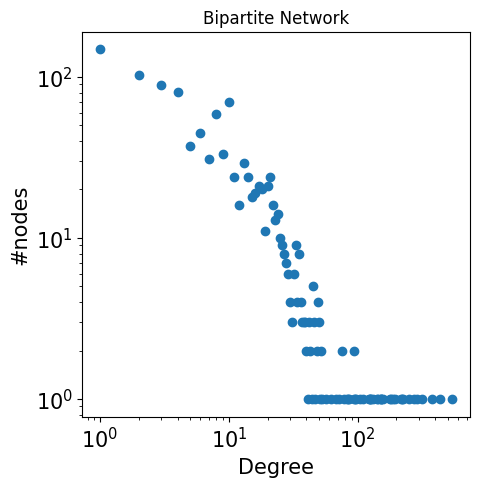

In [5]:
represent_degree_distribution(B,node_list=B.nodes(),scale='log',rep='scatter', title='Bipartite Network') ## Represent the degree distribution of the graph with a scatter plot and log scale


/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_86736/1294712512.py:20: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


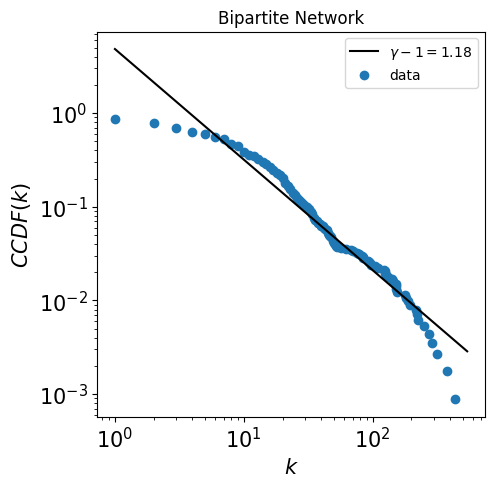

In [29]:
fit_CCDF(B,node_list=B.nodes(), title='Bipartite Network') ## Fit the CCDF of the degree distribution with a power law and represent it in a log-log scale

Species table

Here we identify

generalist bacteria (high degree)
specialists (low degree)

Metabolite table

hub metabolites (used by many species)
rare metabolites (specialized compounds)

In [ ]:
# =========================================================
# ASSUMPTION:
# B is already built and contains:
# - species nodes (bipartite=0)
# - metabolite nodes (bipartite=1)
# - directed edges species ↔ metabolites
# =========================================================

# =========================================================
# SPLIT NODES BY TYPE
# =========================================================

species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 0 or d.get("node_type") == "species"
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 1 or d.get("node_type") == "metabolite"
]

# =========================================================
# DEGREE CALCULATION FUNCTIONS
# =========================================================
#
# In a directed bipartite metabolic network:
# - degree = total interactions (in + out)
# - in-degree = what comes into node
# - out-degree = what leaves node
#
# =========================================================

def compute_degrees(G, nodes):

    results = []

    for n in nodes:

        indeg = G.in_degree(n)
        outdeg = G.out_degree(n)
        total = indeg + outdeg

        results.append({
            "node": n,
            "in_degree": indeg,
            "out_degree": outdeg,
            "total_degree": total
        })

    return pd.DataFrame(results)

# =========================================================
# SPECIES DEGREE ANALYSIS
# =========================================================

species_df = compute_degrees(B, species_nodes)
species_df = species_df.sort_values("total_degree", ascending=False)

print("\n" + "="*60)
print("TOP SPECIES BY DEGREE")
print("="*60)
print(species_df.head(20))

# =========================================================
# METABOLITE DEGREE ANALYSIS
# =========================================================

metabolite_df = compute_degrees(B, metabolite_nodes)
metabolite_df = metabolite_df.sort_values("total_degree", ascending=False)

print("\n" + "="*60)
print("TOP METABOLITES BY DEGREE")
print("="*60)
print(metabolite_df.head(20))

# =========================================================
# SUMMARY STATS
# =========================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\nSpecies degree stats:")
print(species_df["total_degree"].describe())

print("\nMetabolite degree stats:")
print(metabolite_df["total_degree"].describe())


TOP SPECIES BY DEGREE
                             node  in_degree  out_degree  total_degree
838              human colonocyte        120           4           124
843         mouse intestinal cell         60          18            78
106  bacteroides thetaiotaomicron         47          29            76
120        bifidobacterium longum         40          22            62
116         bifidobacterium breve         38          14            52
311              escherichia coli         21          28            49
216       clostridium perfringens         30          18            48
292         enterococcus faecalis         32          15            47
115       bifidobacterium bifidum         30          16            46
97             bacteroides ovatus         31          15            46
112  bifidobacterium adolescentis         31          15            46
446       lactobacillus plantarum         31          14            45
108          bacteroides vulgatus         34          

## Analyzing Bipartite Network individually

In [142]:
# =========================================================
# CENTRALITY MEASURES (Directly from original MultiGraph B)
# =========================================================

degree_centrality = nx.degree_centrality(B)
betweenness_centrality = nx.betweenness_centrality(B)
closeness_centrality = nx.closeness_centrality(B)

# NetworkX requires a simple graph for Eigenvector Centrality
# We cast it inline here so B itself remains completely untouched
B_simple_temp = nx.DiGraph(B) if B.is_directed() else nx.Graph(B)
eigenvector_centrality = nx.eigenvector_centrality(B_simple_temp, max_iter=1000)

# =========================================================
# ASSORTATIVITY
# =========================================================

degree_assortativity = nx.degree_assortativity_coefficient(B)

# =========================================================
# CLUSTERING (Requires undirected simple graph inline)
# =========================================================

B_undirected_temp = B.to_undirected() if B.is_directed() else B
B_undirected_simple = nx.Graph(B_undirected_temp)

clustering_coeffs = nx.clustering(B_undirected_simple)
avg_clustering = nx.average_clustering(B_undirected_simple)

# =========================================================
# COMPILE CENTRALITY RESULTS
# =========================================================

centrality_df = pd.DataFrame({
    "node": list(B.nodes()),
    "degree_centrality": [degree_centrality[n] for n in B.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in B.nodes()],
    "closeness_centrality": [closeness_centrality[n] for n in B.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[n] for n in B.nodes()],
    "clustering_coefficient": [clustering_coeffs[n] for n in B.nodes()]
})

# =========================================================
# PRINT SUMMARY & TOP 5 HIGHEST VALUES PER METRIC
# =========================================================

print("=" * 60)
print("NETWORK CENTRALITY & ASSORTATIVITY ANALYSIS")
print("=" * 60)

print(f"\nDegree Assortativity: {degree_assortativity:.4f}")
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

print("\n" + "=" * 60)
print("TOP 5 NODES FOR EACH METRIC")
print("=" * 60)

metrics = [
    "degree_centrality", 
    "betweenness_centrality", 
    "closeness_centrality", 
    "eigenvector_centrality",
    "clustering_coefficient"
]

for metric in metrics:
    print(f"\nRANKING BY: {metric.upper()}")
    # Sort by the current metric, slice the top 5, and drop index for clean display
    top_5 = centrality_df[["node", metric]].sort_values(metric, ascending=False).head(5)
    print(top_5.to_string(index=False))
    print("-" * 40)

NETWORK CENTRALITY & ASSORTATIVITY ANALYSIS

Degree Assortativity: -0.4235
Average Clustering Coefficient: 0.0000

TOP 5 NODES FOR EACH METRIC

RANKING BY: DEGREE_CENTRALITY
                                                    node  degree_centrality
                                                 acetate           0.482238
                                                     co2           0.388099
l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate)           0.337478
                                     d-glucose (glucose)           0.279751
                                           h2 (hydrogen)           0.256661
----------------------------------------

RANKING BY: BETWEENNESS_CENTRALITY
                                                    node  betweenness_centrality
                                                     co2                0.119737
                                                 acetate                0.107608
l-lactate ([s]-lactate, lactate, d-lactate, [r]-la

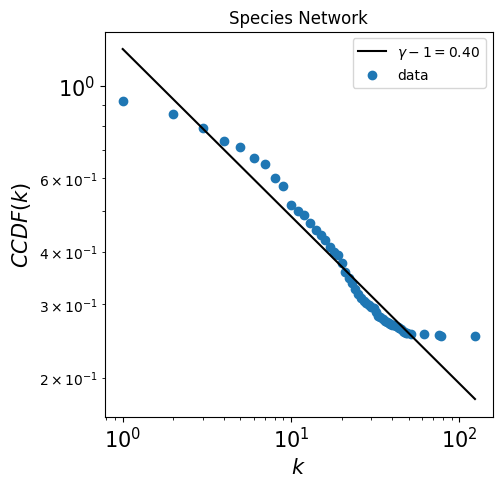

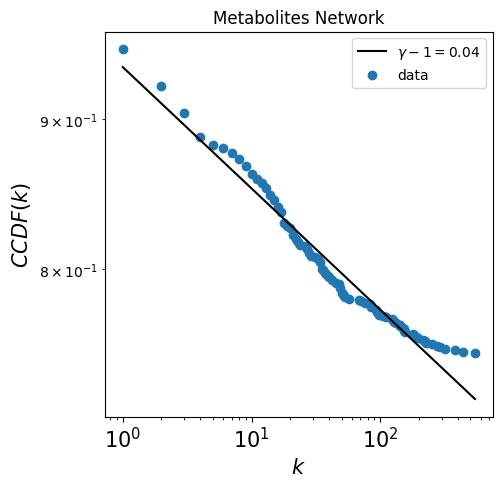

In [31]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 0 or d.get("node_type") == "species"
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 1 or d.get("node_type") == "metabolite"
]

fit_CCDF(B, node_list=species_nodes, title='Species Network')
fit_CCDF(B, node_list=metabolite_nodes, title='Metabolites Network')

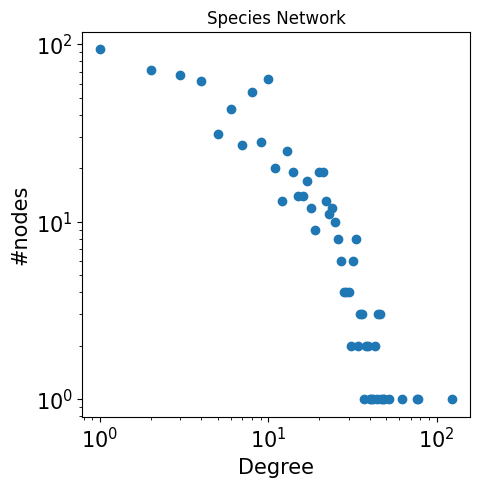

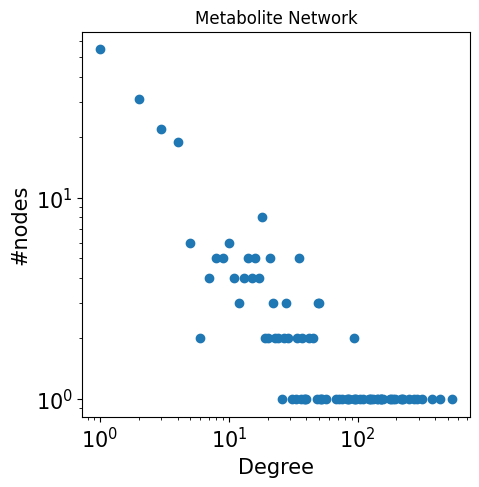

In [39]:
represent_degree_distribution(
    B,
    node_list=species_nodes,
    scale='log',
    rep='scatter',
	title='Species Network'
)

represent_degree_distribution(
    B,
    node_list=metabolite_nodes,
    scale='log',
    rep='scatter',
	title='Metabolite Network'
	
)

## Robustness of the bipartite network 

In [51]:
def largest_component_size(G):

    # convert to undirected for connectivity analysis
    H = G.to_undirected()

    components = list(nx.connected_components(H))

    if len(components) == 0:
        return 0

    return max(len(c) for c in components)


def attack_simulation(G, nodes, strategy="random", centrality=None, steps=50):

    G = G.copy()

    results = []

    # ---------------------------------------------
    # ranking strategy
    # ---------------------------------------------

    if strategy == "random":
        ranked = nodes.copy()

    elif strategy == "degree":
        ranked = sorted(nodes, key=lambda n: G.degree(n), reverse=True)

    elif strategy == "centrality":
        ranked = sorted(nodes, key=lambda n: centrality.get(n, 0), reverse=True)

    else:
        raise ValueError("Unknown strategy")

    # ---------------------------------------------
    # removal loop
    # ---------------------------------------------

    for i in range(steps):

        if len(ranked) == 0:
            break

        if strategy == "random":
            node = random.choice(ranked)
            ranked.remove(node)
        else:
            node = ranked.pop(0)

        if node in G:
            G.remove_node(node)

        results.append({
            "step": i,
            "LCC": largest_component_size(G)
        })

    return pd.DataFrame(results)

In [43]:
betweenness = nx.betweenness_centrality(B)

In [53]:
all_nodes = list(B.nodes())

In [54]:
random_results = attack_simulation(
    B,
    all_nodes,
    strategy="random",
    steps=50
)

In [59]:
targeted_results = attack_simulation(
    B,
    all_nodes,
    strategy="degree",
    steps=50
)

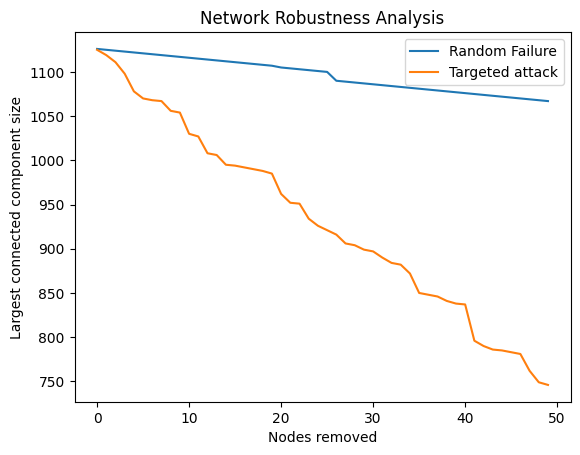

In [60]:
plt.figure()

plt.plot(random_results["step"], random_results["LCC"],
         label="Random Failure")

plt.plot(targeted_results["step"], targeted_results["LCC"],
         label="Targeted attack")

plt.xlabel("Nodes removed")
plt.ylabel("Largest connected component size")
plt.title("Network Robustness Analysis")

plt.legend()
plt.show()

## Robustness of the bipartite network individually

In [44]:
species_attack_random = attack_simulation(
    B,
    species_nodes,
    strategy="random"
)

species_attack_degree = attack_simulation(
    B,
    species_nodes,
    strategy="degree"
)

species_attack_betweenness = attack_simulation(
    B,
    species_nodes,
    strategy="centrality",
    centrality=betweenness
)

In [45]:
metabolite_attack_random = attack_simulation(
    B,
    metabolite_nodes,
    strategy="random"
)

metabolite_attack_degree = attack_simulation(
    B,
    metabolite_nodes,
    strategy="degree"
)

metabolite_attack_betweenness = attack_simulation(
    B,
    metabolite_nodes,
    strategy="centrality",
    centrality=betweenness
)

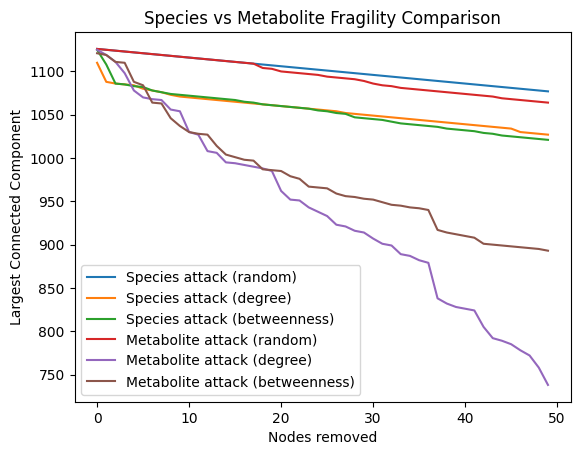

In [50]:
plt.figure()

# Species
plt.plot(species_attack_random["step"], species_attack_random["LCC"],
         label="Species attack (random)")

plt.plot(species_attack_degree["step"], species_attack_degree["LCC"],
         label="Species attack (degree)")

plt.plot(species_attack_betweenness["step"], species_attack_betweenness["LCC"],
         label="Species attack (betweenness)")

# Metabolites
plt.plot(metabolite_attack_random["step"], metabolite_attack_random["LCC"],
         label="Metabolite attack (random)")


plt.plot(metabolite_attack_degree["step"], metabolite_attack_degree["LCC"],
         label="Metabolite attack (degree)")

plt.plot(metabolite_attack_betweenness["step"], metabolite_attack_betweenness["LCC"],
         label="Metabolite attack (betweenness)")

plt.xlabel("Nodes removed")
plt.ylabel("Largest Connected Component")
plt.title("Species vs Metabolite Fragility Comparison")
plt.legend()
plt.show()

## Nestedness

In [66]:
# ---------------------------------------------------------
# UNIQUE NODE LISTS
# ---------------------------------------------------------

species_nodes = sorted(species_nodes)
metabolite_nodes = sorted(metabolite_nodes)

# ---------------------------------------------------------
# INDEX MAPS
# ---------------------------------------------------------

species_index = {
    s: i for i, s in enumerate(species_nodes)
}

metabolite_index = {
    m: j for j, m in enumerate(metabolite_nodes)
}

# ---------------------------------------------------------
# EMPTY MATRIX
# ---------------------------------------------------------

M = np.zeros(
    (len(species_nodes), len(metabolite_nodes)),
    dtype=int
)

# ---------------------------------------------------------
# FILL MATRIX
# ---------------------------------------------------------

for u, v in B.edges():

    u_type = B.nodes[u]["node_type"]
    v_type = B.nodes[v]["node_type"]

    # species -> metabolite
    if u_type == "species":

        s = u
        m = v

    # metabolite -> species
    else:

        s = v
        m = u

    i = species_index[s]
    j = metabolite_index[m]

    M[i, j] = 1

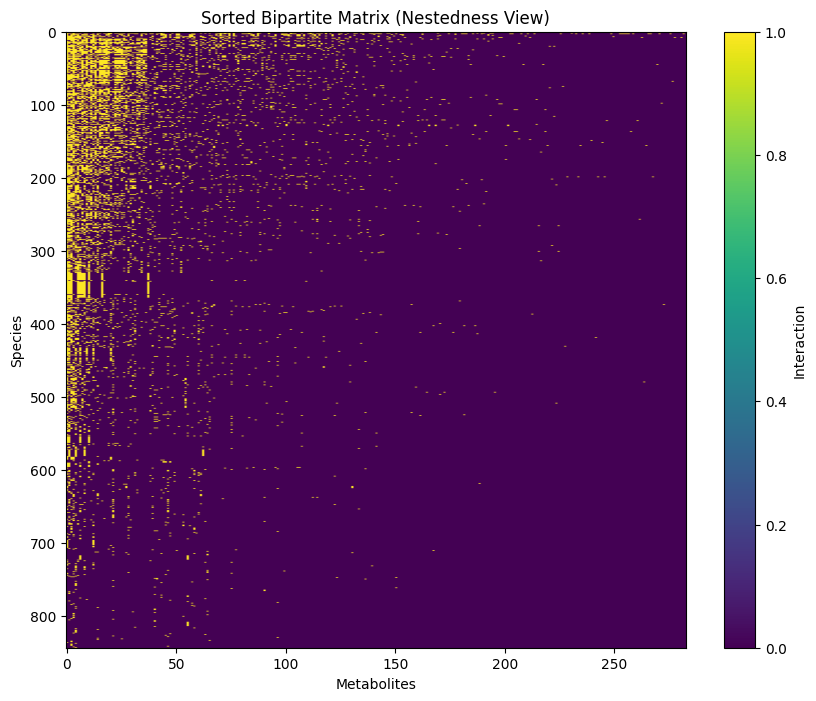

In [69]:
# ---------------------------------------------------------
# sort rows and columns by degree
# ---------------------------------------------------------

row_order = np.argsort(M.sum(axis=1))[::-1]
col_order = np.argsort(M.sum(axis=0))[::-1]

M_sorted = M[row_order][:, col_order]

# ---------------------------------------------------------
# visualize sorted matrix
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(M_sorted, aspect="auto")

plt.title("Sorted Bipartite Matrix (Nestedness View)")
plt.xlabel("Metabolites")
plt.ylabel("Species")

plt.colorbar(label="Interaction")

plt.show()

In [ ]:
# This library doesn't exist but I copy and paste it from the original code 
# in the following repository https://github.com/tsakim/nestedness

class NestednessCalculator(object):
    """Calculates the nestedness of the input matrix.

    The algorithms that have been implemented are:
        - NODF (Nestedness based on Overlap and Decreasing Fill)
    """
    def __init__(self, mat):
        """Initialize the Nestedness calculator and check the input matrix.

        :param mat: binary input matrix
        :type mat: numpy.array
        """
        self.check_input_matrix_is_binary(mat)
        self.check_degrees(mat)

    @staticmethod
    def check_input_matrix_is_binary(mat):
        """Check that the input matrix is binary, i.e. entries are 0 or 1.

        :param mat: binary input matrix
        :type mat: numpy.array

        :raise AssertionError: raise an error if the input matrix is not
            binary
        """
        assert np.all(np.logical_or(mat == 0, mat == 1)), \
            "Input matrix is not binary."

    @staticmethod
    def check_degrees(mat):
        """Check that rows and columns are not completely zero.

        :param mat: binary input matrix
        :type mat: numpy.array

        :raise AssertionError: raise an error if the input matrix has
            completely zero rows or columns.
        """
        assert np.all(mat.sum(axis=1) != 0), \
            "Input matrix rows with only zeros, abort."
        assert np.all(mat.sum(axis=0) != 0), \
            "Input matrix columns with only zeros, abort."

################################################################################
# NODF - Nestedness based on Overlap and Decreasing Fill
################################################################################

    def get_paired_nestedness(self, mat, rows=True):
        """Calculate the paired nestedness along the rows or columns of the.

        :param mat: binary input matrix
        :type mat: numpy.array
        :param rows: if True, pairs are calculated along the rows, if False
            along the columns
        :type rows: bool

        :returns: degree of paired nestedness
        :rtype: float

        The method uses the algorithm described in the `BiMat framework for
        MATLAB <https://bimat.github.io/alg/nestedness.html>`_.
        """
        if rows:
            # consider rows
            po_mat = np.dot(mat, mat.T)
            degrees = mat.sum(axis=1)
        else:
            # consider cols
            po_mat = np.dot(mat.T, mat)
            degrees = mat.sum(axis=0)
        assert len(degrees) == len(po_mat)

        neg_delta = (degrees != degrees[:, np.newaxis])
        deg_matrix = degrees * np.ones_like(po_mat)
        deg_minima = np.minimum(deg_matrix, deg_matrix.T)
        n_pairs = po_mat[neg_delta] / (2. * deg_minima[neg_delta])
        return n_pairs.sum()

    def nodf(self, mat):
        """Calculate the NODF nestedness of the input matrix [AlmeidaNeto]_.

        :param mat: binary input matrix
        :type mat: numpy.array

        :returns: NODF nestedness of the input matrix
        :rtype: float


        The algorithm has been tested by comparison with the `online tool
        provided at <http://ecosoft.alwaysdata.net/>`_
        """
        n_pairs_rows = self.get_paired_nestedness(mat, rows=True)
        n_pairs_cols = self.get_paired_nestedness(mat, rows=False)
        norm = np.sum(np.array(mat.shape) * (np.array(mat.shape) - 1) / 2.)
        nodf = (n_pairs_rows + n_pairs_cols) / norm
        return nodf

In [72]:

calculator = NestednessCalculator(M_sorted)

nodf = calculator.nodf(M_sorted)

print("NODF =", nodf)

NODF = 0.2977012779627041


In [77]:
# =========================================================
# NUMBER OF EDGES (L)
# =========================================================

L = B.number_of_edges()

# =========================================================
# NUMBER OF SPECIES (S)
# =========================================================

S = len([
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0
])

# =========================================================
# NUMBER OF METABOLITES (M)
# =========================================================

M = len([
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "metabolite" or d.get("bipartite") == 1
])

# =========================================================
# CONNECTANCE
# =========================================================

connectance = L / (S * M)

print("=" * 60)
print("BIPARTITE CONNECTANCE")
print("=" * 60)

print(f"Species (S): {S}")
print(f"Metabolites (M): {M}")
print(f"Links (L): {L}")
print(f"Connectance (C): {connectance:.6f}")

# need to check this better

BIPARTITE CONNECTANCE
Species (S): 844
Metabolites (M): 283
Links (L): 9316
Connectance (C): 0.039003


# Competition Network

In [5]:
competition_activities = {

    "Consumption (import)",

    "Consumption (import), Production (export)",

    "Macromolecule degradation"
}

species_to_metabolites = defaultdict(set)

for u, v, d in B.edges(data=True):

    activity = d.get("activity")

    sign = d.get("sign")

    # -----------------------------------------
    # Skip negative interactions
    # -----------------------------------------

    if sign == -1:
        continue

    # -----------------------------------------
    # Keep only competition-related activities
    # -----------------------------------------

    if activity not in competition_activities:
        continue

    # -----------------------------------------
    # Identify species/metabolite
    # -----------------------------------------

    u_type = B.nodes[u].get("node_type")

    if u_type == "species":

        species = u
        metabolite = v

    else:

        species = v
        metabolite = u

    # -----------------------------------------
    # Add metabolite usage
    # -----------------------------------------

    species_to_metabolites[species].add(metabolite)

In [68]:
def structural_characterization (G_net):
    #read the file
    G_net = nx.Graph(G_net)

    #primary characteristics
    print('Number of nodes:', G_net.number_of_nodes())
    print('Number of edges:', G_net.number_of_edges())

    #degree
    degrees = [d for _, d in G_net.degree()]

    min_degree = min(degrees)
    max_degree = max(degrees)
    avg_degree = sum(degrees) / len(degrees)

    print(f"Minimum Degree: {min_degree}")
    print(f"Maximum Degree: {max_degree}")
    print(f"Average Degree: {avg_degree:.2f}")

    #clustering
    avg_clustering = nx.average_clustering(G_net)
    print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

    r = nx.degree_assortativity_coefficient(G_net)
    print(f"Assortativity Coefficient (r): {r:.4f}")

    #paths characteristics
    if nx.is_connected(G_net):
        avg_path = nx.average_shortest_path_length(G_net)
        d = nx.diameter(G_net)
    else:
        largest_cc = max(nx.connected_components(G_net), key=len)
        G_lcc = G_net.subgraph(largest_cc)

        avg_path = nx.average_shortest_path_length(G_lcc)
        d = nx.diameter(G_lcc)

        print("Graph is not connected, using largest connected component")

    print(f"Average Shortest Path Length: {avg_path:.2f}")
    print(f"Diameter: {d}")

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return G_net

# Questions
Which bacteria compete most strongly?

Edge weight are
* number of shared metabolites

In [6]:
G_shared = nx.Graph()

for s in species_nodes:
    G_shared.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    w = len(species_to_metabolites[s1] & species_to_metabolites[s2])

    if w > 0:
        G_shared.add_edge(s1, s2, weight=w)

In [9]:
print("="*60)
print("COMPETITION NETWORK")
print("="*60)

print("Species nodes:", G_shared.number_of_nodes())
print("Competition edges:", G_shared.number_of_edges())

COMPETITION NETWORK
Species nodes: 844
Competition edges: 110890


In [69]:
structural_characterization(G_shared)

Number of nodes: 844
Number of edges: 110890
Minimum Degree: 0
Maximum Degree: 644
Average Degree: 262.77
Average Clustering Coefficient: 0.7461
Assortativity Coefficient (r): 0.1163
Graph is not connected, using largest connected component
Average Shortest Path Length: 1.64
Diameter: 4
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


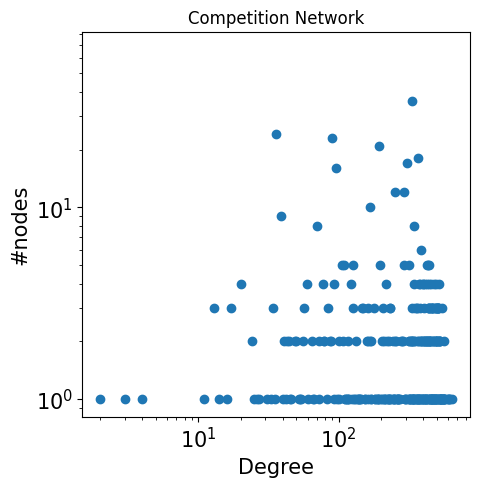

In [59]:
represent_degree_distribution(G_shared,node_list=G_shared.nodes(),scale='log',rep='scatter', title='Competition Network') ## Represent the degree distribution of the graph with a scatter plot and log scale


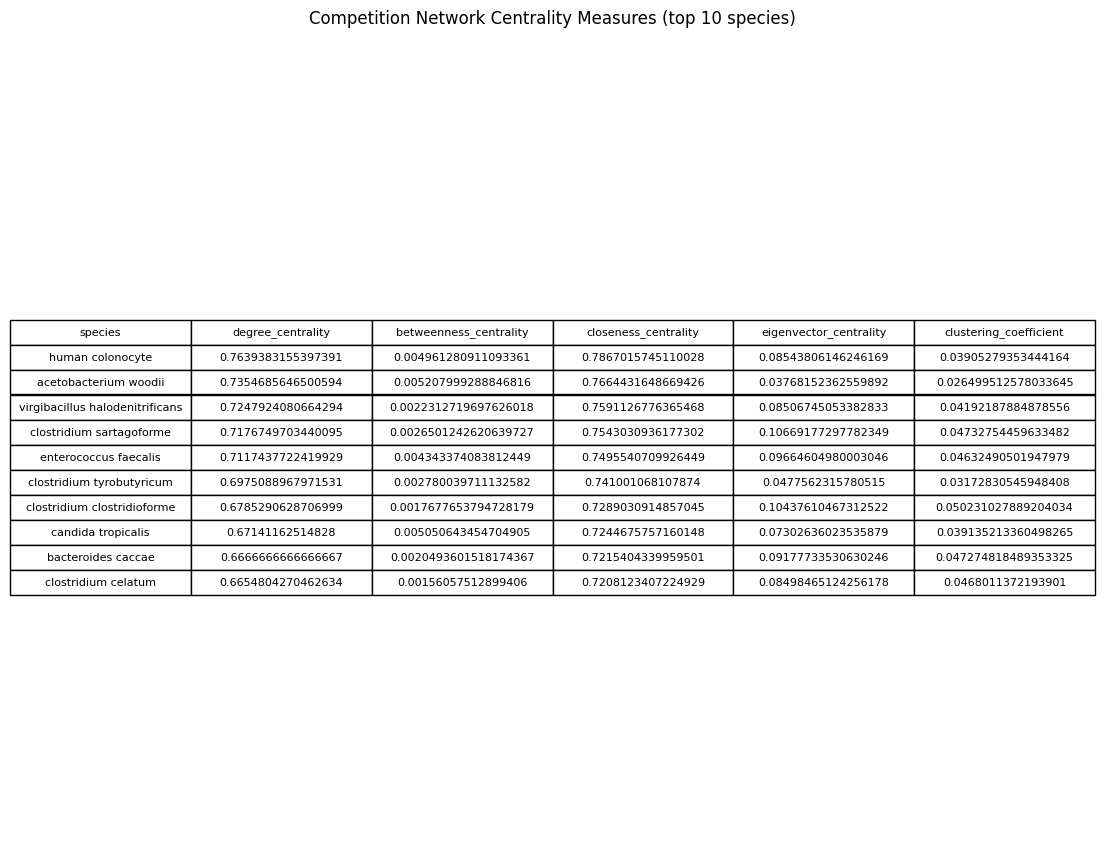

In [71]:
# compute competition network centrality measures
degree_cent = nx.degree_centrality(G_shared)
bet_cent = nx.betweenness_centrality(G_shared, weight="weight")
close_cent = nx.closeness_centrality(G_shared)
eig_cent = nx.eigenvector_centrality(G_shared, weight="weight", max_iter=1000)
clust = nx.clustering(G_shared, weight="weight")

assortativity = nx.degree_assortativity_coefficient(G_shared, weight="weight")
avg_clustering = nx.average_clustering(G_shared, weight="weight")

competition_df = pd.DataFrame({
	"species": list(G_shared.nodes()),
	"degree_centrality": [degree_cent[n] for n in G_shared.nodes()],
	"betweenness_centrality": [bet_cent[n] for n in G_shared.nodes()],
	"closeness_centrality": [close_cent[n] for n in G_shared.nodes()],
	"eigenvector_centrality": [eig_cent[n] for n in G_shared.nodes()],
	"clustering_coefficient": [clust[n] for n in G_shared.nodes()]
})

competition_df = competition_df.sort_values(
	by="degree_centrality",
	ascending=False
).reset_index(drop=True)

# show the top nodes in a matplotlib table
top_n = 10
top_df = competition_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis("off")

table = ax.table(
	cellText=top_df.values,
	colLabels=top_df.columns,
	cellLoc="center",
	loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

ax.set_title(
	f"Competition Network Centrality Measures (top {top_n} species)\n",
	pad=20
)

plt.show()

## Which pairs share the most metabolites?

In [39]:
edges_df = []

for u, v, d in G_shared.edges(data=True):

    edges_df.append({
        "species_1": u,
        "species_2": v,
        "shared_metabolites": d["weight"]
    })

edges_df = pd.DataFrame(edges_df)

edges_df = edges_df.sort_values(
    "shared_metabolites",
    ascending=False
)

print(edges_df.head(20))

                              species_1                     species_2  \
110889                 human colonocyte         mouse intestinal cell   
29496             bifidobacterium breve        bifidobacterium longum   
27848      bifidobacterium adolescentis        bifidobacterium longum   
23311                bacteroides ovatus  bacteroides thetaiotaomicron   
29058           bifidobacterium bifidum        bifidobacterium longum   
29054           bifidobacterium bifidum         bifidobacterium breve   
27844      bifidobacterium adolescentis         bifidobacterium breve   
36437         butyrivibrio fibrisolvens  butyrivibrio proteoclasticus   
27843      bifidobacterium adolescentis       bifidobacterium bifidum   
28635          bifidobacterium animalis        bifidobacterium longum   
110874  virgibacillus halodenitrificans              human colonocyte   
28631          bifidobacterium animalis         bifidobacterium breve   
28630          bifidobacterium animalis       bifid

## modularity

In [9]:
louvain_partition = community_louvain.best_partition(
    G_shared,
    weight="weight",
    random_state=42
)

# ---------------------------------------------------------
# Compute modularity score
# ---------------------------------------------------------

louvain_modularity = community_louvain.modularity(
    louvain_partition,
    G_shared,
    weight="weight"
)

print("=" * 60)
print("LOUVAIN MODULARITY")
print("=" * 60)
print(f"Modularity Q: {louvain_modularity:.4f}")

LOUVAIN MODULARITY
Modularity Q: 0.1899


In [10]:
louvain_modules = defaultdict(list)

for node, module_id in louvain_partition.items():
    louvain_modules[module_id].append(node)

print("\nMODULE SIZES\n")

for module_id, species in louvain_modules.items():

    print(
        f"Module {module_id}: "
        f"{len(species)} species"
    )



MODULE SIZES

Module 0: 199 species
Module 4: 212 species
Module 2: 283 species
Module 3: 83 species
Module 6: 1 species
Module 7: 1 species
Module 8: 1 species
Module 9: 1 species
Module 10: 1 species
Module 11: 1 species
Module 12: 1 species
Module 13: 1 species
Module 14: 1 species
Module 15: 1 species
Module 16: 1 species
Module 17: 1 species
Module 18: 1 species
Module 19: 1 species
Module 20: 1 species
Module 21: 1 species
Module 22: 1 species
Module 23: 1 species
Module 24: 1 species
Module 25: 1 species
Module 26: 1 species
Module 27: 1 species
Module 28: 1 species
Module 29: 1 species
Module 30: 1 species
Module 31: 1 species
Module 32: 1 species
Module 33: 1 species
Module 34: 1 species
Module 35: 1 species
Module 36: 1 species
Module 37: 1 species
Module 38: 1 species
Module 39: 1 species
Module 40: 1 species
Module 41: 1 species
Module 42: 1 species
Module 43: 1 species
Module 44: 1 species
Module 45: 1 species
Module 46: 1 species
Module 47: 1 species
Module 48: 1 species

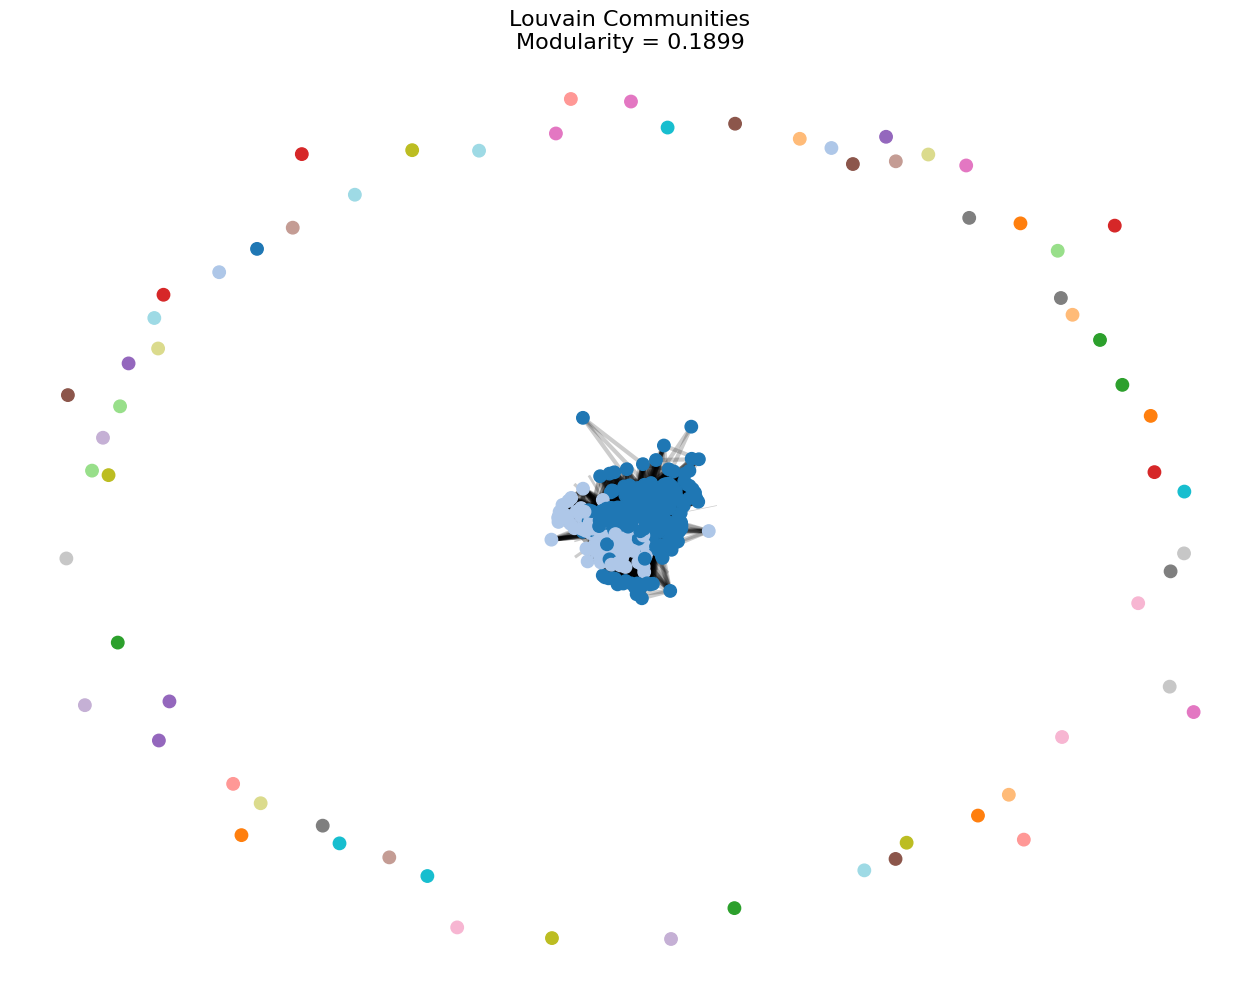

In [49]:
pos = nx.spring_layout(
    G_shared,
    seed=42,
    k=0.15
)

# ---------------------------------------------------------
# Node colors
# ---------------------------------------------------------

node_colors = [
    louvain_partition[node]
    for node in G_shared.nodes()
]

# ---------------------------------------------------------
# Edge widths from weights
# ---------------------------------------------------------

edge_widths = [
    d["weight"] * 3
    for _, _, d in G_shared.edges(data=True)
]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(16, 12))

nx.draw_networkx_nodes(
    G_shared,
    pos,
    node_size=80,
    node_color=node_colors,
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G_shared,
    pos,
    alpha=0.2,
    width=edge_widths
)

plt.title(
    f"Louvain Communities\n"
    f"Modularity = {louvain_modularity:.4f}",
    fontsize=16
)

plt.axis("off")

plt.show()

In [13]:
from networkx.algorithms.community import (
    greedy_modularity_communities
)
from networkx.algorithms.community.quality import modularity


greedy_communities = greedy_modularity_communities(
    G_shared,
    weight="weight"
)

greedy_partition = {}

for i, comm in enumerate(greedy_communities):

    for node in comm:

        greedy_partition[node] = i
        

greedy_modularity = modularity(
    G_shared,
    greedy_communities,
    weight="weight"
)

print("\n")
print("=" * 60)
print("GREEDY MODULARITY")
print("=" * 60)

print(f"Modularity Q: {greedy_modularity:.4f}")



GREEDY MODULARITY
Modularity Q: 0.1688


In [14]:
print("\nMODULE SIZES\n")

for i, comm in enumerate(greedy_communities):

    print(
        f"Module {i}: "
        f"{len(comm)} species"
    )


MODULE SIZES

Module 0: 280 species
Module 1: 278 species
Module 2: 201 species
Module 3: 18 species
Module 4: 1 species
Module 5: 1 species
Module 6: 1 species
Module 7: 1 species
Module 8: 1 species
Module 9: 1 species
Module 10: 1 species
Module 11: 1 species
Module 12: 1 species
Module 13: 1 species
Module 14: 1 species
Module 15: 1 species
Module 16: 1 species
Module 17: 1 species
Module 18: 1 species
Module 19: 1 species
Module 20: 1 species
Module 21: 1 species
Module 22: 1 species
Module 23: 1 species
Module 24: 1 species
Module 25: 1 species
Module 26: 1 species
Module 27: 1 species
Module 28: 1 species
Module 29: 1 species
Module 30: 1 species
Module 31: 1 species
Module 32: 1 species
Module 33: 1 species
Module 34: 1 species
Module 35: 1 species
Module 36: 1 species
Module 37: 1 species
Module 38: 1 species
Module 39: 1 species
Module 40: 1 species
Module 41: 1 species
Module 42: 1 species
Module 43: 1 species
Module 44: 1 species
Module 45: 1 species
Module 46: 1 species
M

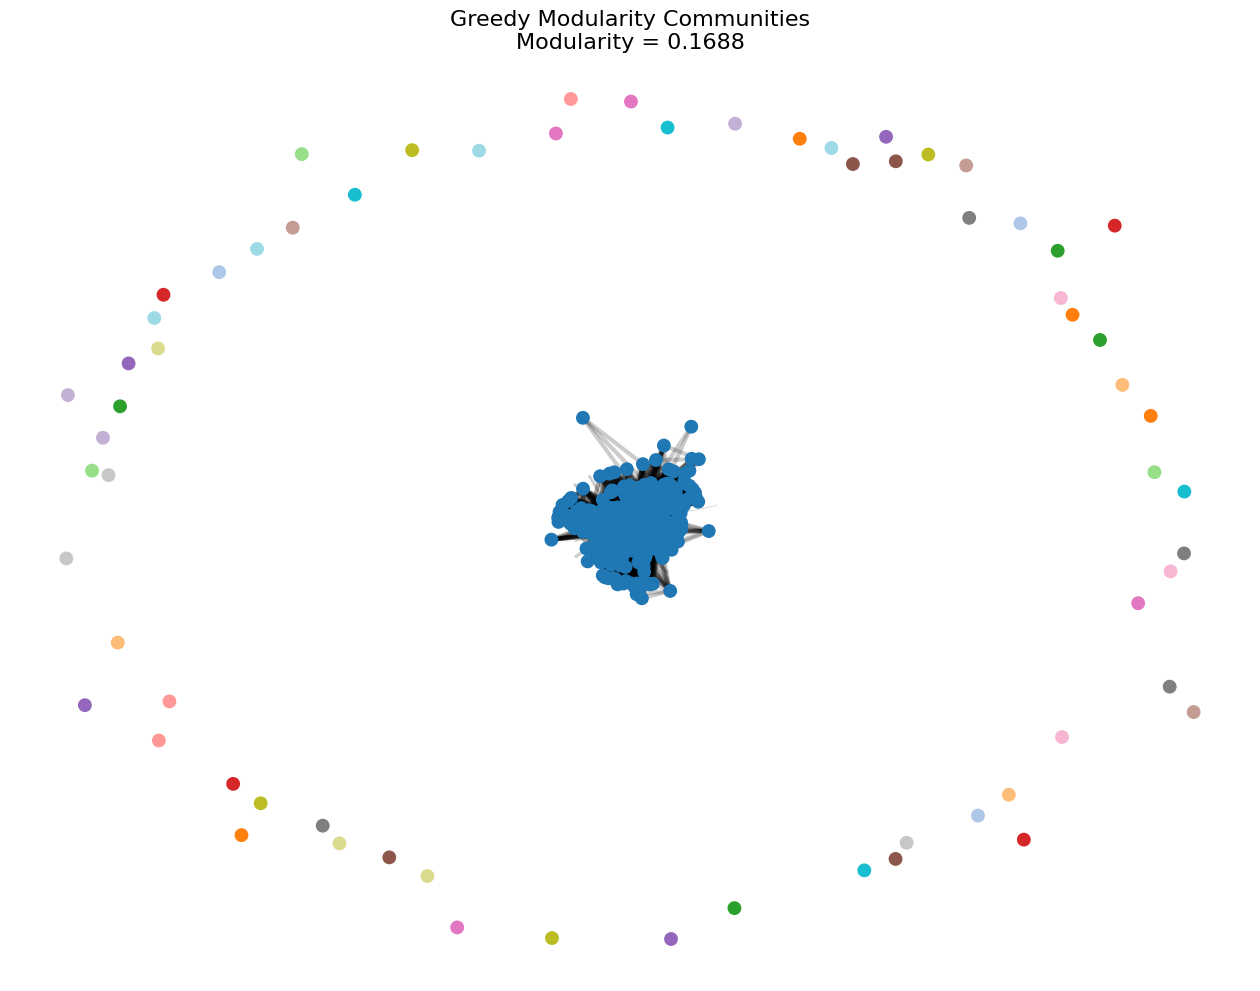

In [15]:
node_colors = [
    greedy_partition[node]
    for node in G_shared.nodes()
]

plt.figure(figsize=(16, 12))

nx.draw_networkx_nodes(
    G_shared,
    pos,
    node_size=80,
    node_color=node_colors,
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G_shared,
    pos,
    alpha=0.2,
    width=edge_widths
)

plt.title(
    f"Greedy Modularity Communities\n"
    f"Modularity = {greedy_modularity:.4f}",
    fontsize=16
)

plt.axis("off")

plt.show()


In [16]:
comparison_df = pd.DataFrame({
    "method": ["Louvain", "Greedy"],
    "modularity": [
        louvain_modularity,
        greedy_modularity
    ],
    "num_modules": [
        len(set(louvain_partition.values())),
        len(greedy_communities)
    ]
})

print("\n")
print("=" * 60)
print("COMPARISON")
print("=" * 60)

print(comparison_df)



COMPARISON
    method  modularity  num_modules
0  Louvain    0.189919           71
1   Greedy    0.168758           71


In [17]:
print("\n")
print("=" * 60)
print("SPECIES PER LOUVAIN MODULE")
print("=" * 60)

for module_id, species in louvain_modules.items():

    print(f"\nMODULE {module_id}")

    for s in sorted(species)[:15]:

        print(" -", s)



SPECIES PER LOUVAIN MODULE

MODULE 0
 - absiella dolichum
 - acholeplasma laidlawii
 - achromobacter xylosoxidans
 - acidovorax delafieldii
 - actinobacillus succinogenes
 - actinosynnema mirum
 - aerococcus viridans
 - aeromonas hydrophila
 - aeromonas salmonicida
 - alistipes indistinctus
 - alistipes onderdonkii
 - alistipes senegalensis
 - alistipes shahii
 - alloprevotella rava
 - anaerobutyricum hallii

MODULE 4
 - acetoanaerobium sticklandii
 - acidaminococcus fermentans
 - acidothermus cellulolyticus
 - actinomyces coleocanis
 - actinomyces oris
 - actinomyces urogenitalis
 - actinomyces viscosus
 - bergeyella zoohelcum
 - bifidobacterium adolescentis
 - bifidobacterium angulatum
 - bifidobacterium animalis
 - bifidobacterium bifidum
 - bifidobacterium breve
 - bifidobacterium catenulatum
 - bifidobacterium dentium

MODULE 2
 - acetobacter pasteurianus
 - acetobacterium woodii
 - acetohalobium arabaticum
 - achromobacter piechaudii
 - acidimicrobium ferrooxidans
 - acidithiob

## Are the competition modules dynamically stable?

In [18]:
# =========================================================
# SELECT MODULE
# =========================================================

target_module = 0

module_species = louvain_modules[target_module]

print("=" * 60)
print("TARGET MODULE")
print("=" * 60)

print(f"Module: {target_module}")
print(f"Species count: {len(module_species)}")

TARGET MODULE
Module: 0
Species count: 199


In [19]:
# =========================================================
# SPECIES INDEX
# =========================================================

species_index = {
    s: i
    for i, s in enumerate(module_species)
}

index_species = {
    i: s
    for s, i in species_index.items()
}

n = len(module_species)

print(f"Matrix size: {n} x {n}")

Matrix size: 199 x 199


In [20]:
A = np.zeros((n, n))

In [21]:
for s1, s2, d in G_shared.edges(data=True):

    if s1 not in species_index:
        continue

    if s2 not in species_index:
        continue

    i = species_index[s1]
    j = species_index[s2]

    weight = d["weight"]

    A[i, j] = weight
    A[j, i] = weight

In [22]:
for i in range(n):

    A[i, i] = 1.0

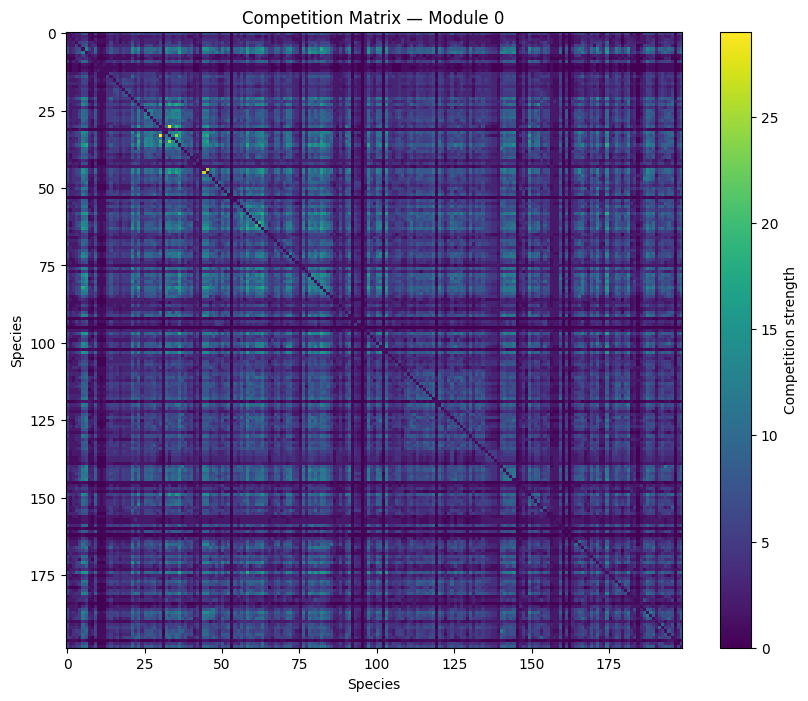

In [23]:
plt.figure(figsize=(10, 8))

plt.imshow(
    A,
    cmap="viridis"
)

plt.colorbar(label="Competition strength")

plt.title(
    f"Competition Matrix — Module {target_module}"
)

plt.xlabel("Species")
plt.ylabel("Species")

plt.show()

In [24]:
# =========================================================
# GROWTH RATES
# =========================================================

r = np.random.uniform(
    0.5,
    1.5,
    size=n
)

print("Growth rates:\n")
print(r)

Growth rates:

[1.36678785 1.35638916 0.96511537 0.71977055 1.02241162 0.56710517
 1.11228954 0.52791536 1.03278769 0.91627001 1.36084059 0.94461791
 1.36730901 0.90042612 0.88009296 1.00192768 0.68997391 0.89626469
 1.19754014 1.37936713 0.63752263 1.17271247 1.2892625  0.75706888
 1.03686986 0.70584026 0.92127512 1.0116743  1.4266237  1.43573589
 1.0642316  0.89272769 1.26213057 0.72102033 0.57604861 1.35796555
 1.40827389 1.47419326 0.94981932 1.2414841  0.95639832 1.39471073
 1.24198036 0.81244888 1.01385928 0.8806619  0.6550711  1.11091631
 0.91445176 0.52759425 1.31609347 1.45609175 0.58072002 0.80926114
 0.68379091 1.24203225 0.6179898  0.57523665 0.76954584 1.37279196
 0.78643858 1.17402817 0.73576548 1.14629219 0.57860784 1.34055762
 1.43167997 1.27902422 1.34572213 1.10656609 0.53131355 1.26641792
 0.77187721 1.49848571 1.32833441 0.59408137 1.11004896 1.25556276
 0.95341666 1.21684762 0.51983543 1.30315251 0.55080252 1.30070177
 0.77601186 0.94700451 1.28257194 0.50244242 1.

In [25]:
# =========================================================
# INITIAL CONDITIONS
# =========================================================

N0 = np.random.uniform(
    0.1,
    1.0,
    size=n
)

print("Initial abundances:\n")
print(N0)

Initial abundances:

[0.69881139 0.87560645 0.63492305 0.33126703 0.39792295 0.81725832
 0.69643347 0.98538095 0.39803504 0.74319406 0.78703957 0.83994936
 0.50256264 0.80635108 0.39697065 0.71840581 0.13433293 0.91077921
 0.82270085 0.30009357 0.66762986 0.89565641 0.22047633 0.96244318
 0.34658172 0.31042611 0.25019967 0.48308423 0.27470782 0.94058623
 0.93292992 0.24128948 0.78263191 0.77684151 0.50471489 0.96657438
 0.10830574 0.45183374 0.64332122 0.85935572 0.19220484 0.84573457
 0.7292677  0.26217574 0.71814406 0.32636969 0.92502729 0.34683092
 0.57873774 0.59902757 0.57310551 0.4890079  0.83812468 0.24993262
 0.54986316 0.92559558 0.43652219 0.88688443 0.10754221 0.31716916
 0.77305148 0.83442351 0.96277125 0.71474091 0.92642405 0.80424029
 0.2932132  0.6432498  0.41342291 0.88870746 0.82666074 0.90328382
 0.15712646 0.40594038 0.78178867 0.92781044 0.92542188 0.87559542
 0.24772121 0.98776317 0.28937208 0.26011256 0.91415222 0.33097759
 0.72661553 0.80758125 0.22681967 0.40933

In [26]:
from scipy.integrate import solve_ivp

In [27]:
# =========================================================
# GENERALIZED LOTKA–VOLTERRA
# =========================================================

def glv(t, N, r, A):

    dNdt = np.zeros_like(N)

    for i in range(len(N)):

        interaction_term = np.sum(
            A[i] * N
        )

        dNdt[i] = (
            r[i]
            * N[i]
            * (1 - interaction_term)
        )

    return dNdt

In [28]:
# =========================================================
# TIME SPAN
# =========================================================

t_span = (0, 100)

t_eval = np.linspace(
    0,
    100,
    1000
)

In [29]:
# =========================================================
# SOLVE ODE SYSTEM

#At its core, solve_ivp (which stands for Solve Initial Value Problem) is a function from Python's scipy.integrate library used to simulate how a dynamic system changes over time.
# =========================================================

solution = solve_ivp(
    glv,
    t_span,
    N0,
    args=(r, A),
    t_eval=t_eval
)

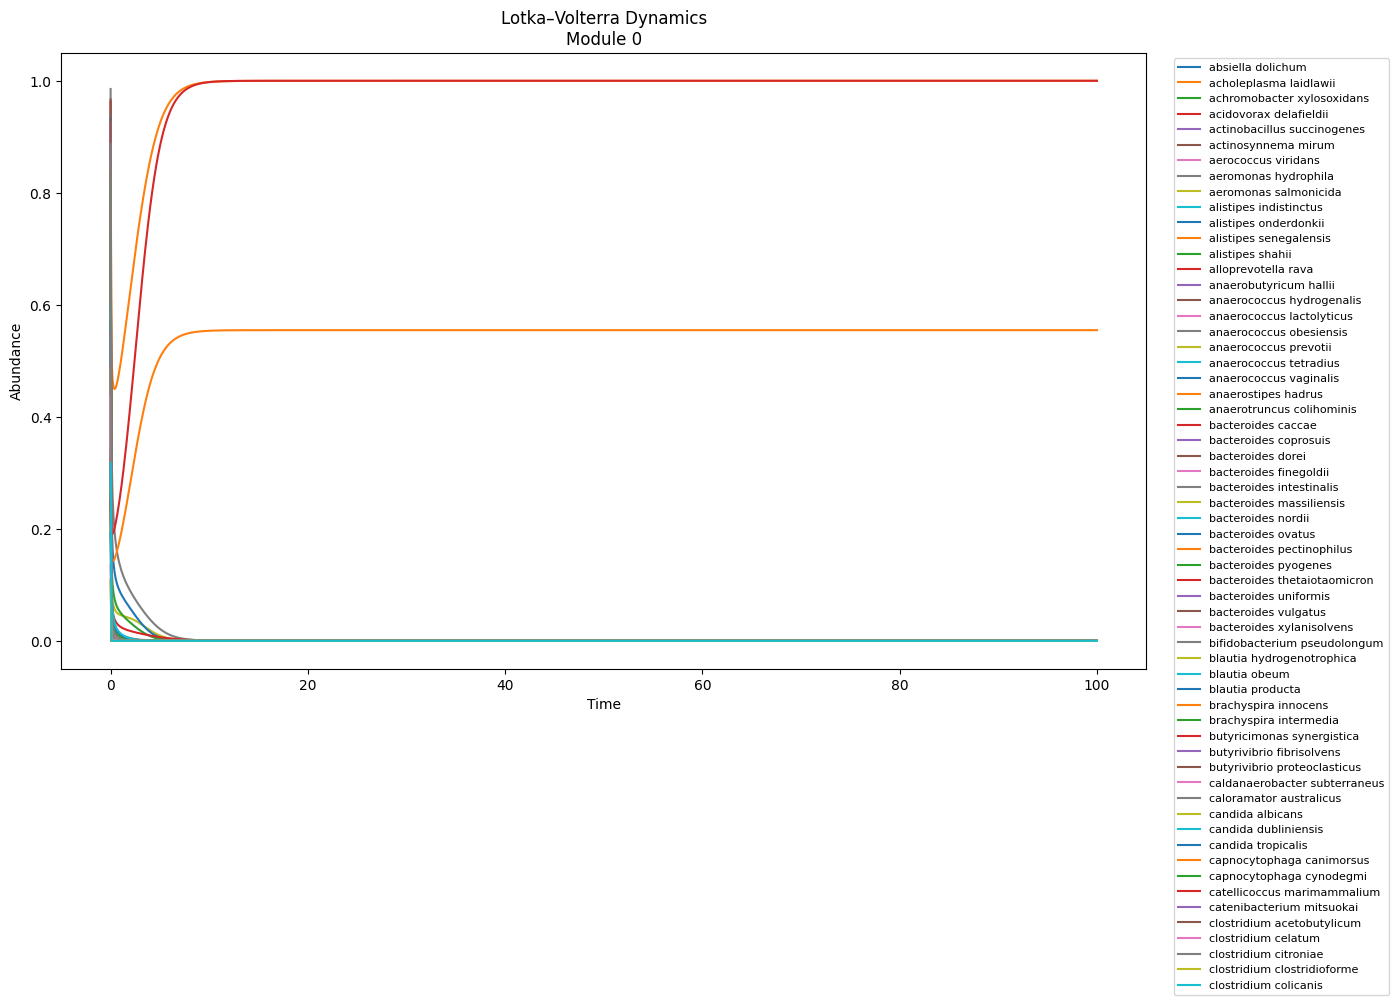

In [58]:
plt.figure(figsize=(14, 8))

for i in range(60):

    plt.plot(
        solution.t,
        solution.y[i],
        label=index_species[i]
    )

plt.xlabel("Time")
plt.ylabel("Abundance")

plt.title(
    f"Lotka–Volterra Dynamics\n"
    f"Module {target_module}"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.show()

In [31]:
final_abundance = solution.y[:, -1]

results_df = pd.DataFrame({
    "species": [
        index_species[i]
        for i in range(n)
    ],
    "final_abundance": final_abundance
})

results_df = results_df.sort_values(
    "final_abundance",
    ascending=False
)

results_df

,species,final_abundance
119,lactobacillus ingluviei,1.000001
75,empedobacter brevis,1.000000
11,alistipes senegalensis,1.000000
102,hungateiclostridium cellulolyticum,1.000000
53,catellicoccus marimammalium,1.000000
...,...,...
110,lactobacillus amylovorus,0.000000
61,clostridium saccharobutylicum,0.000000
169,saccharolobus solfataricus,0.000000
68,coprococcus eutactus,0.000000


In [32]:
EXTINCTION_THRESHOLD = 1e-3

extinct = results_df[
    results_df["final_abundance"]
    < EXTINCTION_THRESHOLD
]

print("=" * 60)
print("EXTINCT SPECIES")
print("=" * 60)

print(extinct)

EXTINCT SPECIES
                           species  final_abundance
103           hungatella hathewayi     5.953933e-06
158               plasmodium vivax     1.129708e-19
43      butyricimonas synergistica     7.007311e-34
139             leptotrichia wadei     3.378599e-40
87               eubacterium yurii     4.284894e-41
..                             ...              ...
110       lactobacillus amylovorus     0.000000e+00
61   clostridium saccharobutylicum     0.000000e+00
169     saccharolobus solfataricus     0.000000e+00
68            coprococcus eutactus     0.000000e+00
0                absiella dolichum     0.000000e+00

[186 rows x 2 columns]


In [33]:
extinct_species = results_df[
    results_df["final_abundance"] < 1e-3
]["species"].tolist()

print(extinct_species)

['hungatella hathewayi', 'plasmodium vivax', 'butyricimonas synergistica', 'leptotrichia wadei', 'eubacterium yurii', 'plasmodium falciparum', 'aeromonas hydrophila', 'aeromonas salmonicida', 'gemella sanguinis', 'peptostreptococcus anaerobius', 'alistipes onderdonkii', 'alistipes shahii', 'halanaerobium praevalens', 'bacteroides xylanisolvens', 'sphingobium japonicum', 'flavobacterium frigoris', 'anaerococcus obesiensis', 'oscillibacter valericigenes', 'achromobacter xylosoxidans', 'anaerococcus vaginalis', 'ruminococcus torques', 'thermotoga maritima', 'tetrapisispora phaffii', 'candida dubliniensis', 'sulfolobus acidocaldarius', 'leptotrichia shahii', 'naumovozyma dairenensis', 'lachnoanaerobaculum saburreum', 'staphylococcus pasteuri', 'streptococcus pasteurianus', 'brachyspira innocens', 'alloprevotella rava', 'acidovorax delafieldii', 'dorea longicatena', 'acholeplasma laidlawii', 'leptotrichia hofstadii', 'lactobacillus suebicus', 'anaerococcus lactolyticus', 'ignavibacterium al

In [34]:
for s in extinct_species:

    print("\n" + "=" * 60)
    print("SPECIES:", s)
    print("=" * 60)

    mets = species_to_metabolites[s]

    print("Number of metabolites:", len(mets))

    print("\nMetabolites:")
    print(sorted(mets))


SPECIES: hungatella hathewayi
Number of metabolites: 17

Metabolites:
['cellobiose', 'd-arabinose (l-arabinose, arabinose, l-arabinopyranose, l-arabinofuranose)', 'd-fructose (fructose)', 'd-galactose', 'd-glucose (glucose)', 'd-mannose (mannose)', 'd-ribose (ribose)', 'd-sorbitol (d-glucitol, sorbitol, glucitol, l-sorbitol, sorbitol)', 'd-xylose (xylose)', 'l-rhamnose (rhamnose, d-rhamnose)', 'lactose', 'maltose', 'melibiose', 'raffinose', 'starch (amylopectin, amylose, 1,4-alpha-d-glucan, pullulan, resistant starch, glycogen)', 'sucrose', 'trehalose']

SPECIES: plasmodium vivax
Number of metabolites: 2

Metabolites:
['d-glucose (glucose)', 'maltose']

SPECIES: butyricimonas synergistica
Number of metabolites: 2

Metabolites:
['d-glucose (glucose)', 'd-mannose (mannose)']

SPECIES: leptotrichia wadei
Number of metabolites: 3

Metabolites:
['d-glucose (glucose)', 'd-turanose', 'maltose']

SPECIES: eubacterium yurii
Number of metabolites: 3

Metabolites:
['d-glucose (glucose)', 'maltos

In [36]:
for s in extinct_species:

    print("\n" + "=" * 60)
    print("SPECIES:", s)
    print("=" * 60)

    if s not in G_shared:
        continue

    neighbors = []

    for nbr in G_shared.neighbors(s):

        weight = G_shared[s][nbr]["weight"]

        neighbors.append((nbr, weight))

    neighbors = sorted(
        neighbors,
        key=lambda x: x[1],
        reverse=True
    )

    print("\nTop competitors:")

    for nbr, w in neighbors[:10]:
        print(f"{nbr:40} {w:.3f}")


SPECIES: hungatella hathewayi

Top competitors:
bacteroides xylanisolvens                16.000
clostridium clostridioforme              16.000
erysipelatoclostridium ramosum           16.000
staphylococcus lentus                    16.000
actinosynnema mirum                      15.000
clostridium sartagoforme                 15.000
eubacterium plexicaudatum                15.000
aerococcus viridans                      14.000
bacteroides pyogenes                     14.000
butyrivibrio fibrisolvens                14.000

SPECIES: plasmodium vivax

Top competitors:
absiella dolichum                        2.000
actinosynnema mirum                      2.000
aerococcus viridans                      2.000
alistipes indistinctus                   2.000
alloprevotella rava                      2.000
anaerobutyricum hallii                   2.000
anaerostipes hadrus                      2.000
anaerotruncus colihominis                2.000
bacteroides caccae                       2.000
bac

In [37]:
all_other_metabolites = set()

for s in species_nodes:

    if s in extinct_species:
        continue

    all_other_metabolites |= species_to_metabolites[s]

In [38]:
for s in extinct_species:

    mets = species_to_metabolites[s]

    unique = mets - all_other_metabolites

    print("\n" + "=" * 60)
    print("SPECIES:", s)
    print("=" * 60)

    print("Unique metabolites:", len(unique))

    print(unique)


SPECIES: hungatella hathewayi
Unique metabolites: 0
set()

SPECIES: plasmodium vivax
Unique metabolites: 0
set()

SPECIES: butyricimonas synergistica
Unique metabolites: 0
set()

SPECIES: leptotrichia wadei
Unique metabolites: 1
{'d-turanose'}

SPECIES: eubacterium yurii
Unique metabolites: 0
set()

SPECIES: plasmodium falciparum
Unique metabolites: 0
set()

SPECIES: aeromonas hydrophila
Unique metabolites: 0
set()

SPECIES: aeromonas salmonicida
Unique metabolites: 0
set()

SPECIES: gemella sanguinis
Unique metabolites: 0
set()

SPECIES: peptostreptococcus anaerobius
Unique metabolites: 0
set()

SPECIES: alistipes onderdonkii
Unique metabolites: 0
set()

SPECIES: alistipes shahii
Unique metabolites: 0
set()

SPECIES: halanaerobium praevalens
Unique metabolites: 0
set()

SPECIES: bacteroides xylanisolvens
Unique metabolites: 0
set()

SPECIES: sphingobium japonicum
Unique metabolites: 0
set()

SPECIES: flavobacterium frigoris
Unique metabolites: 0
set()

SPECIES: anaerococcus obesiensi